In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
h = 0.0001
# Messing around with partial derivatives to build a basic intuition of the behaviour of gradients, matching it with how I expect them to behave from basic calculus

a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h # nudging 'a' by a tiny amount, result should be same as the partial derivative with respect to a
d2 = a*b+c

print('d1', d1)
print('d2', d2)

print('slope (partial derivative with respect to a)', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope (partial derivative with respect to a) -3.000000000010772


In [3]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
c += h # nudging 'c' by a tiny amount, result should be same as the partial derivative with respect to c, which should just be 1
d2 = a*b+c

print('d1', d1)
print('d2', d2)

print('slope (partial derivative with respect to c)', (d2-d1)/h)

d1 4.0
d2 4.0001
slope (partial derivative with respect to c) 0.9999999999976694


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        # We convert from tuple to set, supposedly for efficiency. 
        # These attributes are preceded by a '_' to signal that these are meant for internal use only
        self._prev = set(_children)
        self._op = _op
        self.label = label
        # This attribute tells us how to relate the parent node's derivative to the child nodes. It's initialised as an empty function
        self._backward = lambda: None
        self.grad = 0.0

    # This method is what returns an instance of the class is called
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        # Wrapping 'other' in the Value class if 'other' is a number (assuming that 'other' is one of the two)
        other = other if isinstance(other, Value) else Value(other)
        new = Value(self.data + other.data, (self, other), '+')

        # Derivatives of child nodes for addition is the same as parent node
        # '+=' here so if a node is used multiple times, the 'contributions' to its derivative are counted correctly
        def _backward():
            self.grad += 1.0 * new.grad
            other.grad +=  1.0 * new.grad

        new._backward = _backward
        
        return new
    
    def __mul__ (self, other):
        other = other if isinstance(other, Value) else Value(other)
        new = Value(self.data * other.data, (self, other), '*')

        # Basic differentiation rules
        # The backwards function here is basically filling out what operations should be done to find the derivative of the child nodes with respect to the loss function
        # in the forward pass. Then, the backwards pass actually provides the new.grad value. 
        def _backward():
            self.grad += other.data * new.grad
            other.grad += self.data * new.grad
        new._backward = _backward

        return new
    
    # Fallback operation if the integer is first and python can't do the operation
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def exp(self):
        x = self.data
        new = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += new.data * new.grad
        new._backward = _backward

        return new
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        new = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * new.grad
        new._backward = _backward

        return new
    
    # Automatic backpropagation: Topologically sorts all the nodes (edges only run in one direction) so the gradients of the parent nodes will always be calculated before
    # the gradients of the child nodes
    def backward(self):
        topo = []
        visited = set()

        def build_topo(vertex):
            if vertex not in visited:
                visited.add(vertex)
                for child in vertex._prev:
                    build_topo(child)
                topo.append(vertex)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
a = Value(3.0, label = 'a')
b = Value(2.0, label = 'b')
c = Value(-5.0, label = 'c')

d = a*b
d.label = 'd'
e = d + c
e.label ='e'
f = Value(6.0, label = 'f')
L = f * e
L.label = 'L' # 'Loss function'


In [5]:
from graphviz import Digraph

# This is completely copied code, the sole purpose of this block is to provide a visualisation of the expression tree of a Value class. For Windows, this also requires
# the installation of the Graphviz software

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

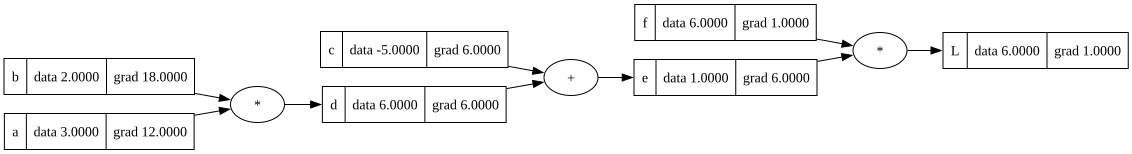

In [6]:
# Visualisation of a forward pass

# Filling out the gradients automatically (backpropagation)
L.backward()

draw_dot(L)

Suppose to be doing some manual backpropagation here but can't be bothered as it's just super basic chain rule $\frac{dz}{dx} = \frac{dz}{dy} \frac{dy}{dx}$  
Note that here the '+' nodes kind of 'distribute' the derivatives to its child nodes

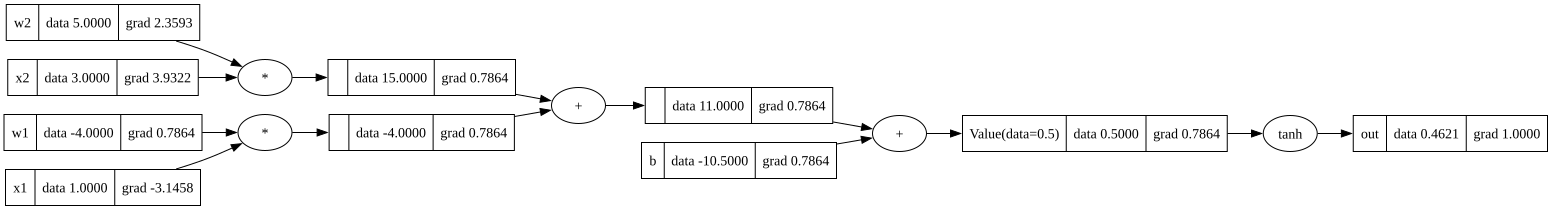

In [7]:
# A more 'neural network' ish example with just one neuron and two weights.

# Inputs
x1 = Value(1.0, label='x1')
x2 = Value(3.0, label='x2')

# Weights
w1 = Value(-4.0, label = 'w1')
w2 = Value(5.0, label='w2')

# Bias of this neuron
b = Value(-10.5, label='b')
x1w1 = x1*w1
x2w2 = x2*w2
x1w1x2w2 = x1w1+x2w2
n = x1w1x2w2 + b
n.label = n
out = n.tanh()
out.label = 'out'

out.backward()

draw_dot(out)


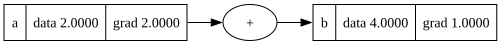

In [8]:
# Test case where one node is used multiple times

a = Value(2.0, label = 'a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)

In [9]:
import torch

In [ ]:
# Checking if this primitive scalar autograd engine agrees with values outputted by PyTorch's autograd
# Here, I'm using pytorch tensors as scalars
# Inputs
x1 = torch.Tensor([1.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([3.0]).double()
x2.requires_grad = True

# Weights
w1 = torch.Tensor([-4.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([5.0]).double()
w2.requires_grad = True

# Bias of this neuron
b = torch.Tensor([-10.5]).double()
b.requires_grad = True

n = x1*w1 + x2*w2 + b

out = torch.tanh(n)

out.backward()
print(out.data.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.46211715726000974
x1 -3.1457909318637096
w1 0.7864477329659274
x2 3.932238664829637
w2 2.359343198897782
